In [3]:
import numpy as np
from reentrykit.trajectory import Vehicle, InitialState, simulate

apollo_ballistic = Vehicle.from_mass_area_cd(
    mass=5357.0,
    reference_area=12.0,
    drag_coefficient=1.2,
    lift_to_drag_ratio=0.0,
    nose_radius=4.661,
)

state = InitialState(
    altitude=85_000.0,  # US1976 ceiling, not 121.92 km
    velocity=11_137.0,
    flight_path_angle=np.deg2rad(-6.93),
)

result = simulate(apollo_ballistic, state)
dV_dt = np.gradient(result.velocity, result.time)
peak_g = -dV_dt.min() / 9.80665

print(f"Pure ballistic Apollo 4 (L/D=0):")
print(f"  Peak g: {peak_g:.1f}")
print(f"  Peak alt: {result.altitude[dV_dt.argmin()]/1000:.1f} km")

Pure ballistic Apollo 4 (L/D=0):
  Peak g: 31.3
  Peak alt: 37.5 km


In [4]:
apollo_lifted = Vehicle.from_mass_area_cd(
    mass=5357.0,
    reference_area=12.0,
    drag_coefficient=1.2,
    lift_to_drag_ratio=0.52,
    nose_radius=4.661,
)

result = simulate(apollo_lifted, state)
dV_dt = np.gradient(result.velocity, result.time)
peak_g = -dV_dt.min() / 9.80665

print(f"Apollo 4 with L/D=0.52:")
print(f"  Peak g: {peak_g:.1f}")
print(f"  Peak alt: {result.altitude[dV_dt.argmin()]/1000:.1f} km")
print(f"  Final alt: {result.altitude[-1]/1000:.1f} km")
print(f"  Altitude rises back? {result.altitude.max() > state.altitude + 1000}")

Apollo 4 with L/D=0.52:
  Peak g: 10.8
  Peak alt: 51.2 km
  Final alt: 0.0 km
  Altitude rises back? True


In [8]:
import importlib
import reentrykit.trajectory
importlib.reload(reentrykit.trajectory)

import inspect
src = inspect.getsource(reentrykit.trajectory._derivatives)
print(src)

def _derivatives(
    time: float,
    state: np.ndarray,
    vehicle: Vehicle,
) -> np.ndarray:
    """Compute the time derivatives of the state vector.

    The state vector is [V, gamma, h, s]:
    - V: velocity magnitude [m/s]
    - gamma: flight-path angle [rad], negative descending
    - h: altitude [m]
    - s: downrange distance [m]

    Called repeatedly by solve_ivp during integration.
    """
    velocity, flight_path_angle, altitude, _downrange = state

    # Atmospheric properties at current altitude. Above the US1976 ceiling
    # (86 km), we treat the atmosphere as vacuum (zero density). This is
    # physically reasonable: density at 86 km is already ~6e-6 kg/m^3, and
    # drag becomes negligible above this altitude. This allows trajectories
    # with sufficient lift to skip back above 86 km without the atmosphere
    # module raising errors.
    if altitude >= MAX_ALTITUDE:
        density = 0.0
    else:
        atmo = us1976(altitude)
        density = atmo.density

In [9]:
with open(r"C:\Users\marco\Projects\Reentrykit\src\reentrykit\trajectory.py") as f:
    contents = f.read()
print("MAX_ALTITUDE guard present:", "if altitude >= MAX_ALTITUDE:" in contents)
print("Number of us1976 calls in file:", contents.count("us1976("))

MAX_ALTITUDE guard present: True
Number of us1976 calls in file: 3


In [10]:
import numpy as np
from reentrykit.trajectory import Vehicle, InitialState, _derivatives
from reentrykit.atmosphere import MAX_ALTITUDE

# Manually test _derivatives with altitude above ceiling
apollo_lifted = Vehicle.from_mass_area_cd(
    mass=5357.0,
    reference_area=12.0,
    drag_coefficient=1.2,
    lift_to_drag_ratio=0.52,
    nose_radius=4.661,
)

# State: velocity, gamma, altitude, downrange
test_state = np.array([8000.0, np.deg2rad(-2.0), 86101.9, 500_000.0])

print(f"MAX_ALTITUDE = {MAX_ALTITUDE}")
print(f"altitude in state = {test_state[2]}")
print(f"altitude >= MAX_ALTITUDE: {test_state[2] >= MAX_ALTITUDE}")

try:
    result = _derivatives(0.0, test_state, apollo_lifted)
    print("Derivatives computed successfully:")
    print(f"  dV/dt = {result[0]}")
    print(f"  dgamma/dt = {result[1]}")
    print(f"  dh/dt = {result[2]}")
    print(f"  ds/dt = {result[3]}")
except Exception as e:
    print(f"Error: {e}")

MAX_ALTITUDE = 86000.0
altitude in state = 86101.9
altitude >= MAX_ALTITUDE: True
Derivatives computed successfully:
  dV/dt = 0.3422471493375811
  dgamma/dt = 1.1739617482943272e-05
  dh/dt = -279.19597362000775
  ds/dt = 7888.633709092767


In [11]:
import shutil
import os
import reentrykit

pkg_dir = os.path.dirname(reentrykit.__file__)
pycache = os.path.join(pkg_dir, "__pycache__")

print(f"Package dir: {pkg_dir}")
print(f"Pycache exists: {os.path.isdir(pycache)}")

if os.path.isdir(pycache):
    for f in os.listdir(pycache):
        print(f"  {f}")
    shutil.rmtree(pycache)
    print("Deleted __pycache__")

Package dir: C:\Users\marco\Projects\Reentrykit\src\reentrykit
Pycache exists: True
  atmosphere.cpython-314.pyc
  trajectory.cpython-314.pyc
  __init__.cpython-314.pyc
Deleted __pycache__


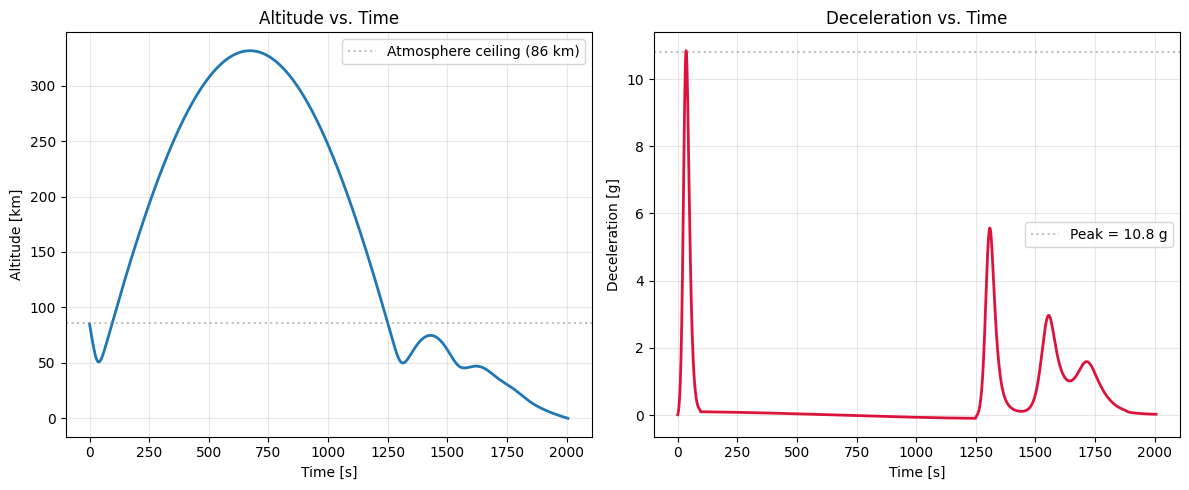


Trajectory summary:
  Flight time:     2006.0 s
  Max altitude:    331.4 km
  Final altitude:  0.0 km
  Final velocity:  73.5 m/s
  Range:           11280.6 km
  Termination:     Ground impact


In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Altitude vs. time
plt.subplot(1, 2, 1)
plt.plot(result.time, result.altitude / 1000, linewidth=2)
plt.xlabel('Time [s]')
plt.ylabel('Altitude [km]')
plt.title('Altitude vs. Time')
plt.grid(alpha=0.3)
plt.axhline(y=86, color='gray', linestyle=':', alpha=0.5, label='Atmosphere ceiling (86 km)')
plt.legend()

# Deceleration vs. time
plt.subplot(1, 2, 2)
dV_dt = np.gradient(result.velocity, result.time)
g_load = -dV_dt / 9.80665
plt.plot(result.time, g_load, linewidth=2, color='crimson')
plt.xlabel('Time [s]')
plt.ylabel('Deceleration [g]')
plt.title('Deceleration vs. Time')
plt.grid(alpha=0.3)
plt.axhline(y=10.8, color='gray', linestyle=':', alpha=0.5, label='Peak = 10.8 g')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nTrajectory summary:")
print(f"  Flight time:     {result.time[-1]:.1f} s")
print(f"  Max altitude:    {result.altitude.max() / 1000:.1f} km")
print(f"  Final altitude:  {result.altitude[-1] / 1000:.1f} km")
print(f"  Final velocity:  {result.velocity[-1]:.1f} m/s")
print(f"  Range:           {result.downrange[-1] / 1000:.1f} km")
print(f"  Termination:     {result.termination_reason}")